In [1]:
%matplotlib inline

In [2]:
import os
from pathlib import Path

import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.rc('figure', figsize=(6, 4.5))
mpl.rcParams['font.size'] = 10
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['figure.facecolor'] = 'w'
mpl.rcParams['hatch.linewidth'] = 0.5
mpl.rcParams['hatch.color'] = '0.25'
# mpl.rcParams['pdf.compression'] = 6
# mpl.rcParams['pdf.use14corefonts'] = True
# mpl.rcParams['pdf.fonttype'] = 42
# mpl.rcParams['font.sans-serif'] = 'DejaVu Sans'

import xarray as xr

from scipy.special import erf
from numpy import pi as π

In [3]:
# trig functions that take degrees

def sind(x):
    return np.sin(np.deg2rad(x))

def cosd(x):
    return np.cos(np.deg2rad(x))

# Make input directory

In [4]:
Path('./INPUT').mkdir(exist_ok=True)
Path('./RESTART').mkdir(exist_ok=True)

# Create grid

In [5]:
grid = 'isotropic'

a = 6370e3
xw = 0
xe = 30
ys = 10
dx = 0.125

xq = np.arange(xw, xe+dx, dx)
xh = np.arange(xw+dx/2, xe, dx)

NX = len(xh)

if grid == 'latlon':
    yn = 45

    dy = 0.5

    yq = np.arange(ys, yn+dy, dy)
    yh = np.arange(ys+dy/2, yn, dy)
    NY = len(yh)
elif grid == 'isotropic': # aka Mercator
    NY = 321
    
    jh = np.arange(NY) + .5
    jq = np.arange(NY+1)

    yq = np.rad2deg(2*np.arctan(np.exp(jq*np.deg2rad(dx))*np.tan(π/4 + np.deg2rad(ys)/2)) - π/2)
    yh = np.rad2deg(2*np.arctan(np.exp(jh*np.deg2rad(dx))*np.tan(π/4 + np.deg2rad(ys)/2)) - π/2)
else:
    RuntimeError('unknown grid type')
    
    
dyq = a*np.deg2rad(np.diff(yh))
dyh = a*np.deg2rad(np.diff(yq))
dxq = a*np.deg2rad(dx)*cosd(yq)
dxh = a*np.deg2rad(dx)*cosd(yh)

Aq = dxq[1:-1]*dyq

The Munk correction for a *no stress* boundary is 

$$
    \hat{v} = \frac{e^{-x/2\delta_m}}{\delta_m}\left(\cos\frac{\sqrt{3} x}{2\delta_m} + \frac{1}{\sqrt{3}} \sin\frac{\sqrt{3} x}{2\delta_m}\right),
$$

where

$$
    \delta_m = \left(\frac{A_h}{\beta}\right)^{1/3}.
$$

The first zero of this occurs at 

$$
    x_0 = \frac{4\pi \delta_m}{3\sqrt{3}}.
$$

If we want $N$ points in this boundary layer, we need

$$
    A_h \ge \beta \left(\frac{3\sqrt{3}}{4\pi}N \Delta x \right)^3,
$$

where

$$
    \beta = \frac{2\Omega}{a}\cos\vartheta \quad\text{and}\quad \Delta x = a \Delta \lambda \cos\vartheta.
$$

We probably want $N \ge 3$. 

Note that the Smagorinski viscosity has a scale of about $A_h \approx (\Upsilon/\pi)^2 U \Delta s$, where $\Upsilon$ is a nondimensional parameter, $U$ is a typical velocity scale, and $\Delta s$ is the grid spacing, defined in MOM6 as

$$
    \Delta s \equiv \frac{2\Delta x \Delta y}{\Delta x + \Delta y}.
$$

For an isotropic grid on the sphere, $\Delta s = \Delta x = \Delta y = a\Delta \lambda \cos\vartheta$. In this case, the Munk constrant gives 

$$
    \Upsilon \ge \frac{9}{4}3^{1/4}\Delta \lambda \sqrt{\frac{a \Omega N^3 \cos^3\vartheta}{2\pi U}}
$$

In [51]:
Ω = 7.29e-5
a = 6370e3
β = 2*Ω*cosd(yq)/a

Δλ = np.radians(0.125)
Δx = a*Δλ*cosd(yq)

N = 3

Ah = np.max(β*(3*np.sqrt(3)*N*Δx/(4*π))**3)
Ah

110.30220255025291

In [57]:
U = 1

Υ = np.max(9/4*3**(1/4)*Δλ*np.sqrt(a*Ω*N**3*cosd(yq)**3/(2*π*U)))
Υ

0.2820348846000029

# Layer configuration

The wave speeds for a 3-layer fluid with a rigid lid are

$$
    c^2 = \frac{1}{2H}\left[g_1'H_1(H-H1) + g_2'(H-H_1 - H_2)(H_1+H_2) \pm \sqrt{[g_1'H_1(H-H_1) - g_2'(H-H_1-H_2)(H_1 + H_2)]^2 + 4g_1' g_2' H_1^2 (H-H_1 - H_2)^2}\right].
$$

If we restrict our attention to the case where $g_1' = g_2' = g'$ and define $H_2 = (r-1)H_1$ and $H = H1 H'$, this becomes

$$
    c^2 = \frac{g' H_1}{2H'}\left[(1+r)H' - 1 - r^2 \pm \sqrt{(1+r^2)^2 - 2 H'(1+3r-r^2+r^3 + H'^2(5-2r-r^2))}\right].
$$

For Cessi's (1990) values of $r = 3$ and $H' = 16$, this is

$$
    c^2 = \frac{54 \pm 2\sqrt{313}}{32}g' H_1.
$$

If $H = 4000$ m, this gives $H_1 = 250$ and $H_2 = 500$. Picking the deformation radius $L_1 = 45$ km at 30º determines the reduced gravity to be

$$
    g' = \frac{32 f^2 L_1^2}{(54 + 2\sqrt{313})H_1} = 0.0154\text{ m s$^{-2}$}.
$$

Then, the two deformation radii are $L_1 = 45$ km and $L_2 = 20.5$ km.

In [6]:
Ω = 7.29e-5
f = 2*Ω*sind(30)

H = 4000
H1 = 250
H2 = 500
H3 = H - H1 - H2
H2 = H - H1
gp = 0.0154

In [7]:
# number of layers
NK = 3

# interface depths
eta = np.array([
       0,
    -175,
    -750,
  -12000, # the last entry can be anything as long as it's deeper than the basin
], dtype=float) 

interface_IC = xr.Dataset(
    {'eta': (['nki'], eta, {'long_name': 'Initial depth of interfaces', 'units': 'meters'})},
)

interface_IC.to_netcdf('INPUT/interface_IC.nc')

# Wind forcing

The wind forcing is the same as in the Parsons-Veronis notebook.

In [8]:
T0 = 20e6
ρ0 = 1035 # Boussinesq reference density
Ω = 7.29e-5
a = 6370e3

lonE = 30 # eastern boundary
λe = np.deg2rad(lonE)

V0 = T0/(a*λe*cosd(25))

def tau(θ, derivative=False):
    if derivative:
        return -(V0*Ω/(1386*np.cos(θ)**2))*np.piecewise(θ, 
                    [θ > np.deg2rad(15), θ <= np.deg2rad(15)],
                    [lambda θ: 315*np.sin(12*θ + π/4) + 994*np.sin(10*θ + π/4) + 1067*np.sin(8*θ + π/4) + 396*np.sin(6*θ + π/4) + 36*np.sin(θ), 
                     lambda θ: (190 + 81*np.sqrt(3))*np.sin(θ)])
    else:
        return (V0*Ω/(1386*np.cos(θ)))*np.piecewise(θ, 
                    [θ > np.deg2rad(15), θ <= np.deg2rad(15)],
                    [lambda θ: 63*np.cos(11*θ + π/4) + 154*np.cos(9*θ + π/4) + 99*np.cos(7*θ + π/4) - 36, 
                     lambda θ: -190 - 81*np.sqrt(3) ])


taux = ρ0*np.repeat(tau(np.deg2rad(yh))[:,np.newaxis], NX+1, axis=1)
tauy = np.zeros((NY+1, NX))



In [9]:
f = 2*Ω*sind(yh)
fq = 2*Ω*sind(yq)
β = 2*Ω*cosd(yh)/a
βq = 2*Ω*cosd(yq)/a
Lxh = a*np.deg2rad(xe-xw)*cosd(yh)
Lxq = a*np.deg2rad(xe-xw)*cosd(yq)


# net Ekman transport
Vek = -tau(np.deg2rad(yh))/f

# Sverdrup transport
wsc = -np.diff(dxh*tau(np.deg2rad(yh)))/Aq
Vsv = (1/βq)[1:-1]*wsc

# net geostrophic transport
wEk = -np.diff(dxh*tau(np.deg2rad(yh))/f)/Aq
Vg = (1*fq/βq)[1:-1]*wEk

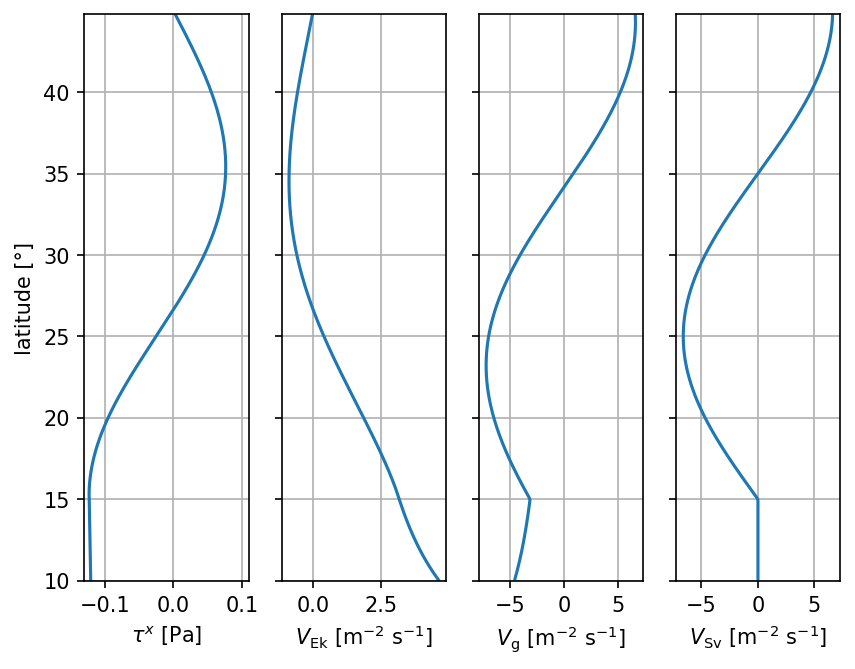

In [10]:
fig, axs = plt.subplots(ncols=4, sharey=True, figsize=(6.5, 5))

ax = axs[0]
ax.plot(taux[:,0], yh)
ax.set_xlim(-.13, .11)
ax.set_xlabel(r'$\tau^x$ [Pa]')
ax.set_ylabel('latitude [\N{DEGREE SIGN}]')

ax = axs[1]
ax.plot(Vek, yh)
ax.set_xlabel(r'$V_\mathrm{Ek}$ [m$^{-2}$ s$^{-1}$]')

ax = axs[2]
ax.plot(Vg, yq[1:-1], '-')
# ax.set_xlim([-24, 24])
ax.set_xlabel(r'$V_\mathrm{g}$ [m$^{-2}$ s$^{-1}$]')

ax = axs[3]
ax.plot(Vsv, yq[1:-1])
# ax.set_xlim([-24, 24])
ax.set_xlabel(r'$V_\mathrm{Sv}$ [m$^{-2}$ s$^{-1}$]')

ax.set_ylim([yq[0], yq[-1]])

for ax in axs:
#     ax.axhline(33.5, ls='--', color='k')
    ax.grid()

fig.savefig('wind_forcing.pdf', bbox_inches='tight')
fig.savefig('wind_forcing.png', bbox_inches='tight', dpi=150)


In [11]:
# MOM6 expects xq and yq to have be missing the last point
forcing = xr.Dataset(coords={
    'yh': (['yh'], yh), 
    'xh': (['xh'], xh),
    'yq': (['yq'], yq[:-1]), 
    'xq': (['xq'], xq[:-1]),
})

forcing['STRESS_X'] = (['yh', 'xq'], taux[:,:-1], {'long_name': 'Zonal Momentum Flux', 'units': 'Pa'})
forcing['STRESS_Y'] = (['yq', 'xh'], tauy[:-1,:], {'long_name': 'Meridional Momentum Flux', 'units': 'Pa'})

forcing.to_netcdf('INPUT/forcing.nc')

forcing

<xarray.Dataset>
Dimensions:   (yh: 321, xh: 240, yq: 321, xq: 240)
Coordinates:
  * yh        (yh) float64 10.06 10.18 10.31 10.43 ... 44.46 44.55 44.64 44.73
  * xh        (xh) float64 0.0625 0.1875 0.3125 0.4375 ... 29.69 29.81 29.94
  * yq        (yq) float64 10.0 10.12 10.25 10.37 ... 44.42 44.5 44.59 44.68
  * xq        (xq) float64 0.0 0.125 0.25 0.375 0.5 ... 29.5 29.62 29.75 29.88
Data variables:
    STRESS_X  (yh, xq) float64 -0.1208 -0.1208 -0.1208 ... 0.003364 0.003364
    STRESS_Y  (yq, xh) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

Read back in after running the model to make sure it took

In [14]:
ds = xr.open_dataset('forcing__0001_003.nc')
forcing_diag = ds
ds.close()

FileNotFoundError: [Errno 2] No such file or directory: b'/Users/cwolfe/work/Gyres+MOC/MOM6-examples/ocean_only/gyre_moc/flat/3layer/0.25/forcing__0001_003.nc'

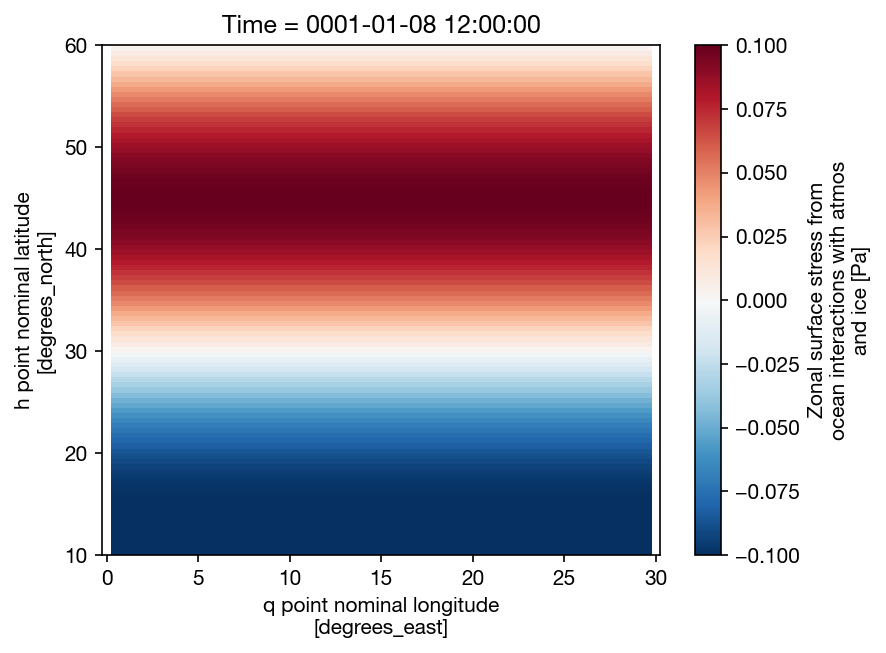

In [23]:
forcing_diag.taux.isel(Time=-1).plot()